In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import scipy.stats as stats

In [2]:
df=pd.read_csv("noisy_email_spam_dataset.csv")
df

,label,email_text
0,spam,Hot deal!!! buy followers!!! http://boost-soci...
1,ham,"Hey,\nI think there is a typo in the file."
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...
3,spam,click fast!!!! http://prize-drop.win
4,ham,<br>Don't forget to submit the assignment.
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...
7,spam,limited time!!!! FREE gift card!!! http://gift...
8,spam,hey u!!! win iphone!!! go --> http://scamlink....
9,spam,Winner!!! send ur details ASAP!!! http://claim...


In [3]:
# Data quality check
print("Shape:", df.shape)
print("Missing:", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (50, 2)
Missing: label         0
email_text    0
dtype: int64
Duplicates: 0


In [4]:
df["char_count"]=df["email_text"].str.len()
df

,label,email_text,char_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53
1,ham,"Hey,\nI think there is a typo in the file.",41
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105
3,spam,click fast!!!! http://prize-drop.win,36
4,ham,<br>Don't forget to submit the assignment.,42
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51
7,spam,limited time!!!! FREE gift card!!! http://gift...,58
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54


In [5]:
df["word_count"]=df["email_text"].str.split().apply(len)
df

,label,email_text,char_count,word_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5
1,ham,"Hey,\nI think there is a typo in the file.",41,10
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9
3,spam,click fast!!!! http://prize-drop.win,36,3
4,ham,<br>Don't forget to submit the assignment.,42,6
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6


In [6]:
df["url_count"]=df["email_text"].str.count("http?://")
df

,label,email_text,char_count,word_count,url_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1
3,spam,click fast!!!! http://prize-drop.win,36,3,1
4,ham,<br>Don't forget to submit the assignment.,42,6,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1


In [7]:
df["excl_count"]=df["email_text"].str.count("!")
df

,label,email_text,char_count,word_count,url_count,excl_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6


In [8]:
df["html_count"]=df["email_text"].str.count("<")
df

,label,email_text,char_count,word_count,url_count,excl_count,html_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6,0
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9,6
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4,0
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0,1
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6,2
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7,0
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7,0
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6,0
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6,0


In [9]:
import emoji
all_emojis_chars = emoji.EMOJI_DATA.keys()
emojis_lst=list(all_emojis_chars)
def count_emojis(text):
    count=0
    for char in text:
        if char in emojis_lst:
            count+=1
    return count
df["emoji_count"]=df["email_text"].apply(count_emojis)
df

,label,email_text,char_count,word_count,url_count,excl_count,html_count,emoji_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6,0,0
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9,6,0
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4,0,0
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0,1,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6,2,0
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7,0,0
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7,0,0
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6,0,0
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6,0,0


In [10]:
df.columns

Index(['label', 'email_text', 'char_count', 'word_count', 'url_count',
       'excl_count', 'html_count', 'emoji_count'],
      dtype='object')

In [11]:
# Fixed drop (errors='ignore' to be safe)
df.drop(columns=["emojis_count"], errors='ignore', inplace=True)
df

,label,email_text,char_count,word_count,url_count,excl_count,html_count,emoji_count
0,spam,Hot deal!!! buy followers!!! http://boost-soci...,53,5,1,6,0,0
1,ham,"Hey,\nI think there is a typo in the file.",41,10,0,0,0,0
2,spam,<html><body>CONGRATS!!! u won $1000!!! click <...,105,9,1,9,6,0
3,spam,click fast!!!! http://prize-drop.win,36,3,1,4,0,0
4,ham,<br>Don't forget to submit the assignment.,42,6,0,0,1,0
5,spam,<div>last chance!!! 90% OFF!!! http://super-sa...,60,5,1,6,2,0
6,spam,OMG!!! unbelievable deal!!!! http://crazy-offe...,51,4,1,7,0,0
7,spam,limited time!!!! FREE gift card!!! http://gift...,58,6,1,7,0,0
8,spam,hey u!!! win iphone!!! go --> http://scamlink....,52,8,1,6,0,0
9,spam,Winner!!! send ur details ASAP!!! http://claim...,54,6,1,6,0,0


<Axes: >

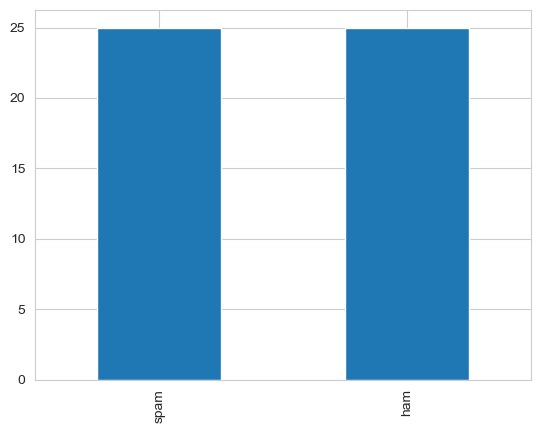

In [12]:
df["label"].value_counts().plot(kind="bar")

<Axes: xlabel='char_count', ylabel='Count'>

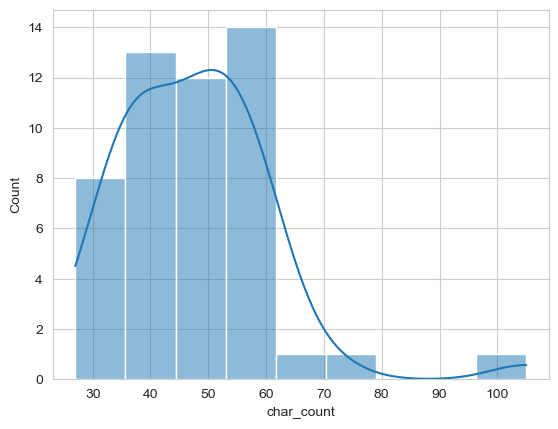

In [13]:
sns.histplot(df["char_count"], kde=True)

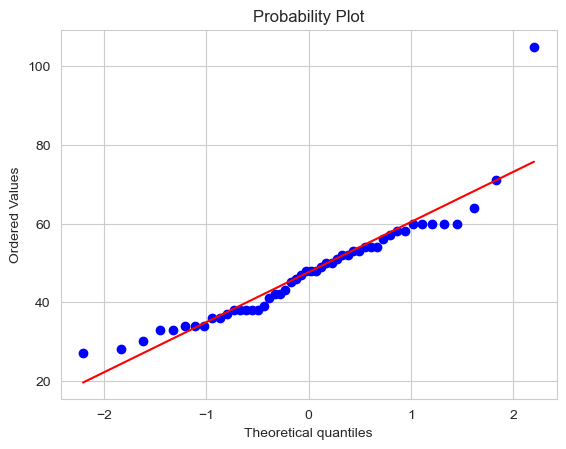

In [14]:
stats.probplot(df["char_count"],dist="norm",plot=plt)
plt.show()

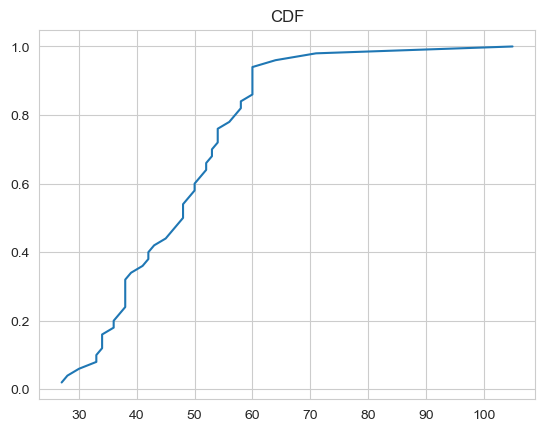

In [15]:
def cdf(data):
    x=np.sort(data)
    y=np.arange(1,len(x)+1)/len(x)
    plt.plot(x,y)
    plt.title('CDF')
    plt.show()
cdf(df["char_count"])

<Axes: xlabel='word_count', ylabel='Count'>

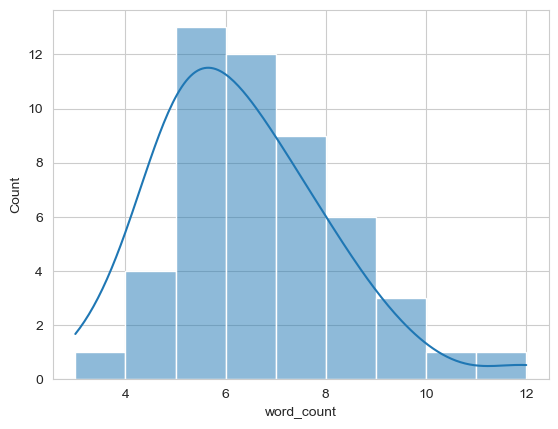

In [16]:
sns.histplot(df["word_count"], kde=True)

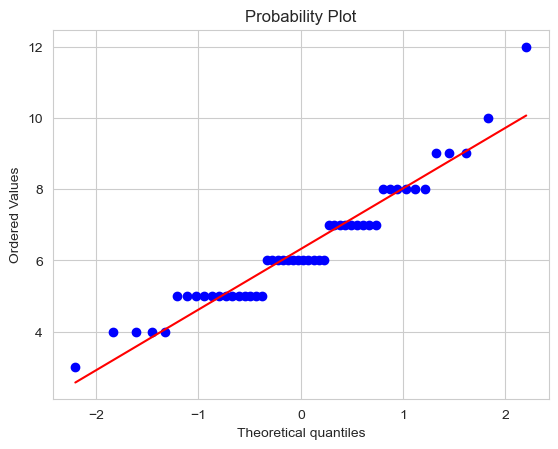

In [17]:
stats.probplot(df["word_count"],dist="norm",plot=plt)
plt.show()

In [18]:
from scipy.stats import skew, kurtosis
print("Skew:", skew(df["word_count"]))
print("Kurtosis:", kurtosis(df["word_count"]))

Skew: 0.8323619427889246
Kurtosis: 1.0631007942443889


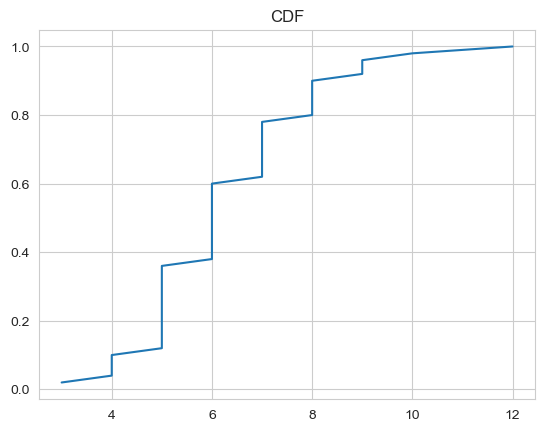

In [19]:
cdf(df["word_count"])

<Axes: xlabel='url_count', ylabel='Count'>

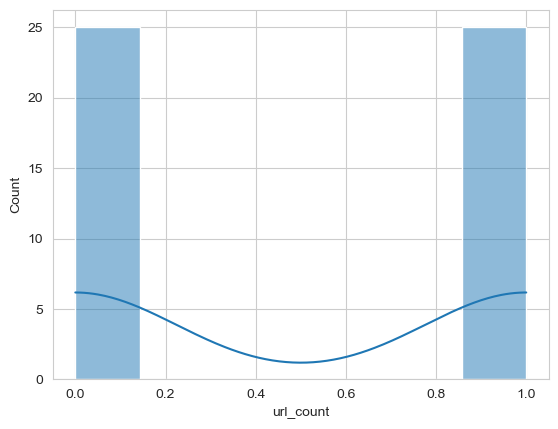

In [20]:
sns.histplot(df["url_count"], kde=True)

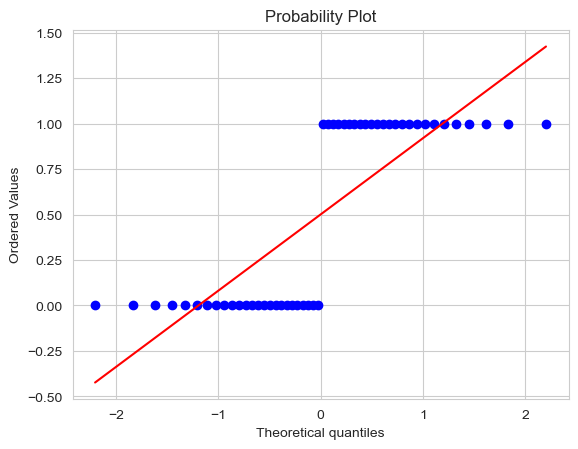

In [21]:
stats.probplot(df["url_count"],dist="norm",plot=plt)
plt.show()

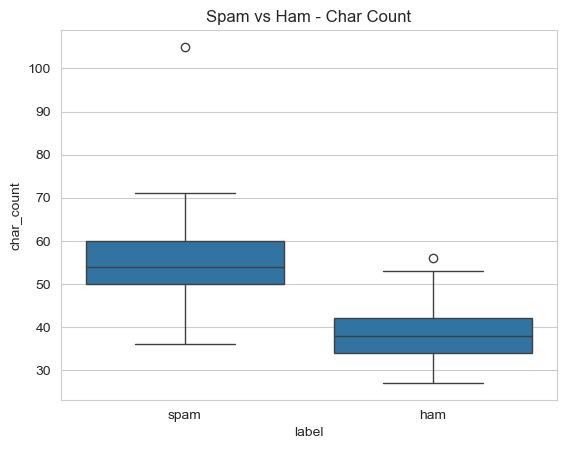

In [22]:
sns.boxplot(x="label",y="char_count",data=df)
plt.title("Spam vs Ham - Char Count")
plt.show()

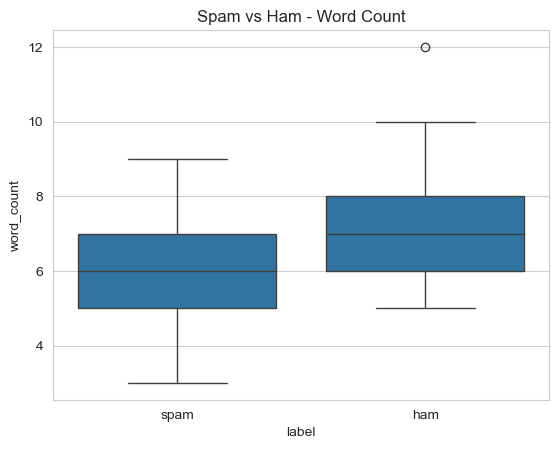

In [23]:
sns.boxplot(x="label",y="word_count",data=df)
plt.title("Spam vs Ham - Word Count")
plt.show()

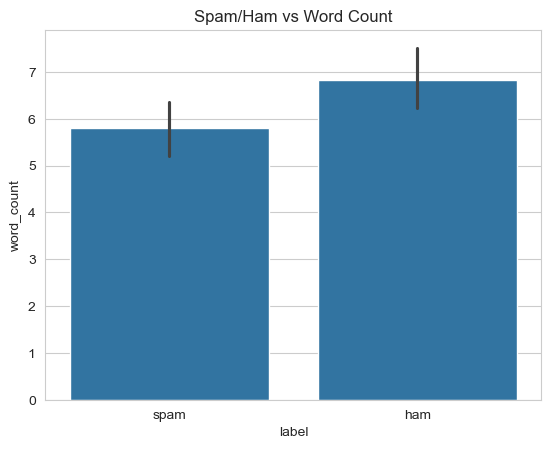

In [24]:
sns.barplot(x="label",y="word_count",data=df)
plt.title("Spam/Ham vs Word Count")
plt.show()

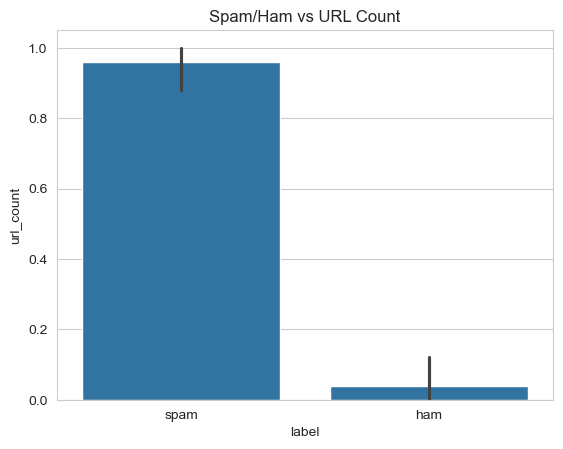

In [25]:
sns.barplot(x="label",y="url_count",data=df)
plt.title("Spam/Ham vs URL Count")
plt.show()

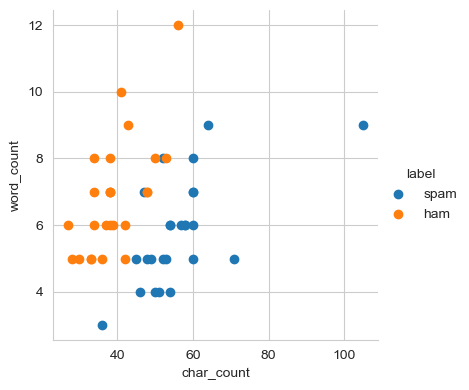

In [26]:
sns.FacetGrid(df,hue="label",height=4).map(plt.scatter,"char_count","word_count").add_legend()
plt.show()

## Enhancements Added
- Data quality checks.
- Fixed var names/typos.
- Better titles.
- histplot (modern distplot replacement).
- Run cell-by-cell.